In [42]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# чтение датасета

In [43]:
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

print(f'train:\n {train_df.head()}',  f'test:\n {test_df.head()}', sep='\n')



train:
    ID     crim    zn  indus  chas    nox     rm   age     dis  rad  tax  \
0   1  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296   
1   2  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242   
2   4  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222   
3   5  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222   
4   7  0.08829  12.5   7.87     0  0.524  6.012  66.6  5.5605    5  311   

   ptratio   black  lstat  medv  
0     15.3  396.90   4.98  24.0  
1     17.8  396.90   9.14  21.6  
2     18.7  394.63   2.94  33.4  
3     18.7  396.90   5.33  36.2  
4     15.2  395.60  12.43  22.9  
test:
    ID     crim    zn  indus  chas    nox     rm    age     dis  rad  tax  \
0   3  0.02729   0.0   7.07     0  0.469  7.185   61.1  4.9671    2  242   
1   6  0.02985   0.0   2.18     0  0.458  6.430   58.7  6.0622    3  222   
2   8  0.14455  12.5   7.87     0  0.524  6.172   96.1  5.9505    5  311   
3   9  0.21124  12.5   7.8

In [44]:
print(f'train:\n {train_df.describe()}',  f'test:\n {test_df.describe()}', sep='\n')

train:
                ID        crim          zn       indus        chas         nox  \
count  333.000000  333.000000  333.000000  333.000000  333.000000  333.000000   
mean   250.951952    3.360341   10.689189   11.293483    0.060060    0.557144   
std    147.859438    7.352272   22.674762    6.998123    0.237956    0.114955   
min      1.000000    0.006320    0.000000    0.740000    0.000000    0.385000   
25%    123.000000    0.078960    0.000000    5.130000    0.000000    0.453000   
50%    244.000000    0.261690    0.000000    9.900000    0.000000    0.538000   
75%    377.000000    3.678220   12.500000   18.100000    0.000000    0.631000   
max    506.000000   73.534100  100.000000   27.740000    1.000000    0.871000   

               rm         age         dis         rad         tax     ptratio  \
count  333.000000  333.000000  333.000000  333.000000  333.000000  333.000000   
mean     6.265619   68.226426    3.709934    9.633634  409.279279   18.448048   
std      0.703952  

In [45]:
# пропуски
print(f'train: {train_df.isnull().sum()}')
print(f'\ntest: {test_df.isnull().sum()}')

train: ID         0
crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
black      0
lstat      0
medv       0
dtype: int64

test: ID         0
crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
black      0
lstat      0
dtype: int64


# матрица кореляций и гистограмма расп-ия medv
чтобы понять, что сильнее всего влияет на MEDV

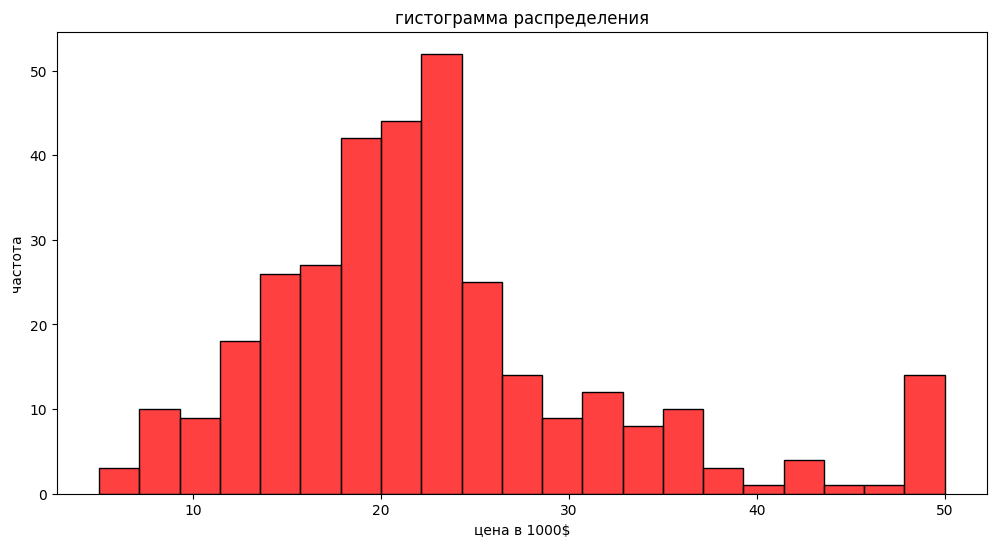

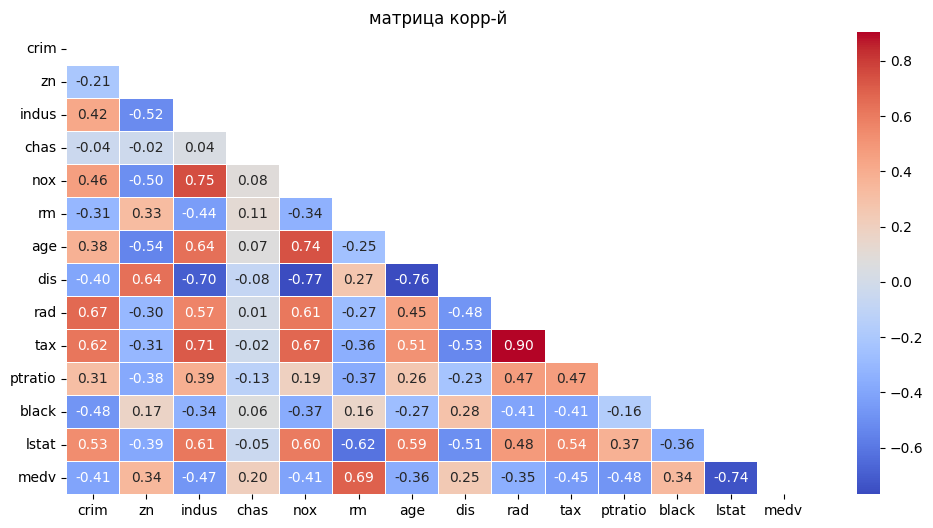

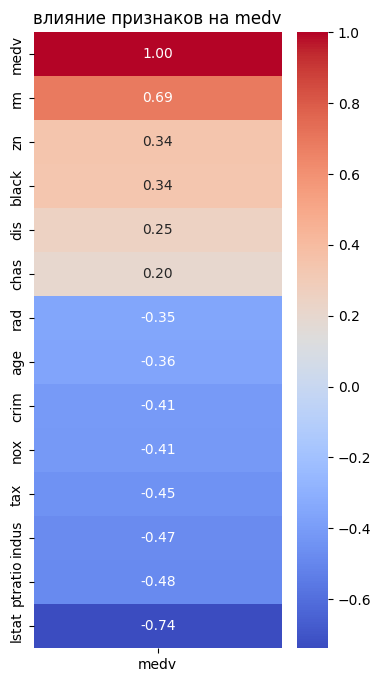

In [ ]:
# гистограмма распределения medv
plt.figure(figsize=(12, 6))
sns.histplot(train_df['medv'],  color='red')
plt.xlabel('цена в 1000$')
plt.ylabel('частота')
plt.title('гистограмма распределения')
plt.show()

# матрица корр-й
plt.figure(figsize=(12,  6))
corr_mat = train_df.drop('ID', axis=1).corr()
mask = np.triu(np.ones_like(corr_mat, dtype=bool))
sns.heatmap(corr_mat, 
            annot=True, 
            mask=mask, 
            cmap='coolwarm', 
            fmt='.2f', 
            linewidths=0.5
)
plt.title('матрица корр-й')
plt.show()

# чтобы проще было делаем один столбец для medv
plt.figure(figsize=(4, 8))
sns.heatmap(corr_mat[['medv']].sort_values(by='medv', ascending=False), 
            annot=True, 
            cmap='coolwarm', 
            fmt=".2f")
plt.title('влияние признаков на medv')
plt.show()